# Estimate Cohort Size Using Predicted ROI

In [1]:
import os
from datetime import datetime
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown

In [2]:
PROJ_ROOT = Path.cwd().parent

In [3]:
assert load_dotenv(dotenv_path=PROJ_ROOT.parent / ".env")

In [4]:
import cc_churn.costs as costs
import cc_churn.visualization as vzu
import r2.io_utils as r2io
from utils.df_utils import show_df

## About

In this notebook, we will identify the cohort of at-risk churners that should be to be targeted by the client's team.

We'll use the following

1. best ML model's prediction probabilities
2. estimate of the Return on Investment (ROI) from successfully targeting these customers, that is calculated from the features in the data

to identify this cohort.

### Use-Case Context

As mentioned in the project scope, the dataset provided to us by the client represents historical customer behavior where the churn outcome is already known. So, the purpose of the trained model is not to act on these historical customers, but to simulate how it would perform if deployed on similar customers in practice. By applying the model to all customers and ranking them by predicted risk of churn (`y_pred_proba`), we can estimate the financial impact if the client had proactively targeted the top-N at-risk customers at that time. The resulting ROI analysis is therefore retrospective since we are performing it on historicla customers but forward-looking in its intent, as it estimates the expected business impact of deploying the model on future customers with similar characteristics (features) and size (~10,000).

This allows the client (credit card division manager) to determine an optimal targeting strategy under realistic assumptions about targeting (intervention) cost and effectiveness. So, the analysis in this notebook will identify this cohort by selecting the customers who most *efficiently* maximize the total ROI out of all ~10,000 customers.

Finally, we assume two scenarios about the client's available budget and make recommendations based for each scenario.

### Relevant Assumptions

We will use the same assumptions made during the project scoping

1. intervention (targeting) success rate of 40%
2. intervention (targeting) cost of $50 per churned customer
3. three sources of fee revenue earned from each customer based on
   - number of credit card transacitons (assumed to be 2%)
   - credit card balance (assumed to be 18%, compared to 15-20% in Canada and 20-30% in the U.S.)
   - credit card exposure (fees determined based on category of card; see the `Card_category` column of the data)
4. other terms
   - loyalty discount factor of 0.9 (or 10% per year)
   - expected remaining tenure of 3 years
5. future customers behave like those characterized by this dataset of ~10,100 customers data provided to us by the client for use in this project

Please see the project scope for more details about how these assumptions are used to calcuate Customer Lifetime Value (CLV), savings and ROI. Here, a custom Python function `get_costs()` is defined in `src/cc_churn/costs.py` to estimate ROI based on customer attributes from the data and using the above assumptions.

### Outputs

Based on the deliverables in [this project's scoping document](https://github.com/edesz/credit-card-churn/blob/main/references/01_proposal.md#project-deliverables), this notebook produces a single file with the at-risk customers (i.e. the cohort), their features, their predicted probaility (to churn) and their business metrics will be exported to a file.

## User Inputs

In [5]:
# columns to load
columns = [
    "clientnum",
    "card_category",
    "total_revolv_bal",
    "total_trans_amt",
    "model_name",
    "y_pred_proba",
    "y_pred",
    "best_decision_threshold",
    "is_churned",
]

# costs
# # revenue from transactions (bank earns #% of transaction volume)
interchange_rate = 0.02
# # revenue from revolving balance (~20% interest)
apr = 0.18
# # fee revenue from credit card exposure (modeled from card type)
card_fees = {"Blue": 0, "Silver": 50, "Gold": 100, "Platinum": 200}
tenure_years = 3
discount = 0.9
# # percentage of churners who can be convinced to stay (i.e. success rate
# # of saving a churning customer)
success_rate = 0.40
# # cost of intervention to get a single customer to not churn (discounts,
# # call center time, retention offers, etc.)
intervention_cost = 50
# # maximum number of customers that can be targeted based on client's budget
num_customers_max = 100

# predictions prefix
r2_key_pred = "2026-04-13/all_predictions__"

In [6]:
account_id = os.getenv("ACCOUNT_ID")
access_key_id = os.getenv("ACCESS_KEY_ID")
secret_access_key = os.getenv("SECRET_ACCESS_KEY")
bucket_name = os.getenv("BUCKET_NAME")

s3_client = boto3.client(
    "s3",
    endpoint_url=f"https://{account_id}.r2.cloudflarestorage.com",
    aws_access_key_id=access_key_id,
    aws_secret_access_key=secret_access_key,
    region_name="auto",
)

# costs
multiplier = (1 - discount**tenure_years) / (1 - discount)

## Load Data with Predictions

Load predictions for all available customers

In [7]:
%%time
df_all_pred = r2io.pandas_read_filtered_parquets_r2(
    s3_client, bucket_name, r2_key_pred, columns
).astype({"card_category": 'category', "model_name": 'category'})
print(f"Got {len(df_all_pred):,} rows of all available data")
_ = show_df(df_all_pred)
with pd.option_context('display.max_columns', None):
    display(df_all_pred.head(1))

Got 10,127 rows of all available data


,num_missing,num_unique,dtype
clientnum,0,10127,int32[pyarrow]
card_category,0,4,category
total_revolv_bal,0,1974,double[pyarrow]
total_trans_amt,0,5033,double[pyarrow]
model_name,0,1,category
y_pred_proba,0,8883,double[pyarrow]
y_pred,0,2,bool[pyarrow]
best_decision_threshold,0,1,double[pyarrow]
is_churned,0,2,int8[pyarrow]


Shape: 10,127 rows X 9 columns, Memory Usage: 402.753 KB


,clientnum,card_category,total_revolv_bal,total_trans_amt,model_name,y_pred_proba,y_pred,best_decision_threshold,is_churned
0,714283458,Blue,0.0,4064.0,HistGradientBoostingClassifier,0.005326,False,0.732324,0


CPU times: user 78.1 ms, sys: 7 ms, total: 85.1 ms
Wall time: 420 ms


Use model predictions of all data to extract best decision threshold

In [8]:
best_decision_threshold = (
    df_all_pred["best_decision_threshold"].head(1).squeeze()
)

Extract name of best ML model from model predictions

In [9]:
best_model_name = df_all_pred["model_name"].head(1).squeeze()

## Estimate Business Metrics

Calculate business metrics from targeting all customers predicted to churn

In [10]:
%%time
df_business_metrics, _, _ = costs.get_cost(
    df_all_pred,
    best_decision_threshold,
    interchange_rate,
    apr,
    card_fees,
    multiplier,
    success_rate,
    intervention_cost,
)
_ = show_df(df_business_metrics)
with pd.option_context('display.max_columns', None, 'display.max_colwidth', None):
    display(df_business_metrics.head(1))

,num_missing,num_unique,dtype
clientnum,0,1604,int32[pyarrow]
card_category,0,4,category
total_revolv_bal,0,470,double[pyarrow]
total_trans_amt,0,1224,double[pyarrow]
model_name,0,1,category
y_pred_proba,0,1524,double[pyarrow]
y_pred,0,1,bool[pyarrow]
best_decision_threshold,0,1,double[pyarrow]
is_churned,0,2,int8[pyarrow]
interchange_rev,0,1224,double[pyarrow]


Shape: 1,604 rows X 27 columns, Memory Usage: 283.516 KB


,clientnum,card_category,total_revolv_bal,total_trans_amt,model_name,y_pred_proba,y_pred,best_decision_threshold,is_churned,interchange_rev,interest_rev,fee_rev,annual_rev,clv,success_rate,expected_savings,true_savings,cum_pred_savings,cum_true_savings,n,random_savings,total_intervention_cost,ROI,ROI_pred,ROI_error,ROI_percent,ROI_percent_pred
0,720243933,Blue,0.0,2784.0,HistGradientBoostingClassifier,0.997936,True,0.732324,1,55.68,0.0,0,55.68,150.8928,0.4,10.232562,10.35712,10.232562,10.35712,1,124.973184,50,0.207142,0.204651,1.202634,20.71424,20.465123


CPU times: user 49.7 ms, sys: 1.92 ms, total: 51.6 ms
Wall time: 51 ms


**Notes**

1. The following metrics are calculated per customer, and are discussed in the [project scoping document](https://github.com/edesz/credit-card-churn/blob/main/references/01_proposal.md)
   - `interchange_rev`
     - revenue earned from number of credit card transactions performed, earned from *n*th customer
   - `interest_rev`
     - revenue from credit card interest due to a credit card balance, earned from *n*th customer
   - `fee_rev`
     - revenue from credit card exposure, earned from *n*th customer
   - `annual_rev`
     - annual revenue earned from *n*th customer
   - `clv`
     - CLV of *n*th customer
   - `expected_savings`
     - predicted savings from targeting the *n*th customer
   - `true_savings`
     - true savings from targeting the *n*th customer
2. The following columns show cumulative inputs needed to calculate the return on investment after targeting the top customers
   - `n`
     - number of at-risk customers to target
     - customers are sorted in reverse chronological order of prediction probability and then ranked, starting at 1
       - `n` is the rank
   - `total_intervention_cost`
     - total cost to client to intervene to try to get single customer to revert their decision to churn
   - `cum_pred_savings`
     - cumulative prediced savings after targeting `n` at-risk customers
   - `cum_true_savings`
     - cumulative true savings after targeting `n` at-risk customers
   - `ROI`
     - true return on investment from targeting at-risk customers (`n`)
   - `ROI_pred`
     - predicted return on investment from targeting at-risk customers
   - `ROI_error`
     - error in predicted return on investment from targeting at-risk customers
   - `ROI_percent`
     - true ROI expressed as a percentage
     - better than `ROI` for reporting
   - `ROI_percent_pred`
     - predicted ROI expressed as a percentage
     - better than `ROI_pred` for reporting
2. The business metrics are only calculated for customers that are predicted to churn since these are the customers that are candidates for targeting by the client's team. For this reason, there are fewer rows in the business metrics `DataFrame` (`df_business_metrics`) than in the `DataFrame` with the ML model predictions for all available data (`df_all_pred`).
3. ROI is a business-focused Key Performance Indicator (KPI). It accounts for both both costs and gains. So, total ROI (`ROI_percent_pred`) provides a better assessment of the impact of targeting the cohort than total savings (`cum_pred_savings`). So, the predicted ROI is the KPI that should be (a) reported to the client and (b) used to estimate the size of cohort (number of customers to target).

## Estimate Cohort Size - Optimal Number of Customers to Target (`N`)

### Plot Cumulative ROI versus Number of Predicted Churners

Plot true and predicted expected savings and ROI curves to visualize the following

1. true ROI
2. predicted ROI

using all available data

CPU times: user 19.3 ms, sys: 21 μs, total: 19.3 ms
Wall time: 30.7 ms


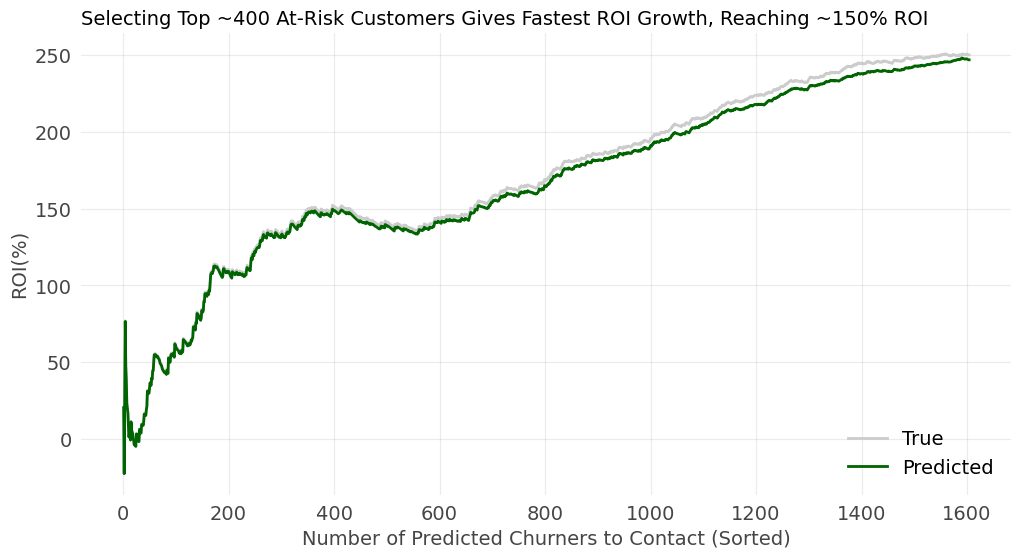

In [11]:
%%time
vzu.plot_roi_curves(
    df_business_metrics['n'],
    df_business_metrics['ROI_percent'],
    df_business_metrics['ROI_percent_pred'],
    ptitle=(
        'Selecting Top ~400 At-Risk Customers Gives Fastest ROI Growth, '
        'Reaching ~150% ROI'
    ),
    legend_loc='lower right',
    xlabel=f"Number of Predicted Churners to Contact (Sorted)",
    ylabel="ROI(%)",
    grid_line_opacity=0.25,
    ticklabel_font_size=14,
    axis_label_font_size=14,
    title_font_size=14,
    axis_font_color='#454545',
    line_colors={'Predicted': 'darkgreen', 'True': '#cccccc'},
    fig_size=(12, 6),
)

Generally, as more top at-risk customers are targeted and successfully reverted the ROI also increases. This makes sense since we are recovering lost credit card revenue from these customers if they decide not to cancel their services at the bank.

We can see there are three regions in this chart.

The first region (called the *top 400* region) occurs between 0 and approximately 400. The top 400 at-risk customers are found here. Excluding an initial noisy period at the beginning, corresponding to the top 50 customers, the ROI increases fastest of the three regions from 0 to ~150%.

The second region (*middle dip*) shows a dip in the ROI. This occurs when the top 400 to the top 560 customers are selected. As more at-risk customers are selected in this region, the ROI decreases instead of increasing, as it did in the *top 400* region. This is not expected.

Finally, in the third region (*tail*), the ROI increases again as more customers are selected, but at a slower rate than in the first region.

Below, we add columns to the business metrics data that contains the

1. name of the region for each predicted churner among all existing customers
2. check if row is a false positive

In [12]:
df_business_metrics = df_business_metrics.assign(
    region=lambda df: (
        pd.cut(
            df["n"],
            bins=[1, 400, 560, len(df)],
            labels=["top_400", "middle_dip_region", "tail_region"],
            include_lowest=True,
            right=True,
        )
    ),
    is_false_positive=lambda df: (df["y_pred"] == 1) & (df["is_churned"] == 0),
)

### Characterize Regions of the Chart

Extract the following business metrics and metadata per region

1. start of each region (`n_start`)
2. end of each region (`n_end`)
3. number of customers in each region (`n_customers`)
4. average predicted churn rate (`churn_rate`)
5. average prediction probability (`avg_proba`)
6. minimum prediction probability (`min_proba`)
7. average false positive rate (`avg_fpr`)
7. average predicted CLV (`avg_clv`)
8. average predicted savings (`avg_expected_savings_per_customer`)

In [13]:
df_regions_business_ml_metrics = df_business_metrics.groupby("region").agg(
    n_start=("n", "min"),
    n_end=("n", "max"),
    n_customers=("n", "count"),
    churn_rate=("is_churned", "mean"),
    avg_proba=("y_pred_proba", "mean"),
    min_proba=("y_pred_proba", "min"),
    avg_fpr=("is_false_positive", "mean"),
    avg_clv=("clv", "mean"),
    avg_expected_savings_per_customer=("expected_savings", "mean"),
)

Extract the correlation between predicted probability and predicted savings (`proba_vs_expected_savings_corr`) per region

In [14]:
df_proba_savings_corr = (
    df_business_metrics.groupby("region")
    .apply(lambda x: x["y_pred_proba"].corr(x["expected_savings"]))
    .rename("proba_vs_expected_savings_corr")
)

Combine all metrics per region

In [15]:
df_n_regions_summary = pd.concat(
    [df_regions_business_ml_metrics, df_proba_savings_corr],
    axis=1,
).transpose()

df_n_regions_summary.style.apply(
    lambda x: ["background-color: yellow"] * len(x),
    axis=1,
    subset=(
        [
            "churn_rate",
            "avg_proba",
            "min_proba",
            "avg_fpr",
            "avg_clv",
            "avg_expected_savings_per_customer",
            "proba_vs_expected_savings_corr",
        ],
        ["middle_dip_region"],
    ),
)

region,top_400,middle_dip_region,tail_region
n_start,1,401,561
n_end,400,560,1604
n_customers,400,160,1044
churn_rate,0.997500,0.968750,0.873563
avg_proba,0.990277,0.980417,0.902230
min_proba,0.983164,0.977367,0.732376
avg_fpr,0.002500,0.031250,0.126437
avg_clv,314.008513,253.292182,569.469121
avg_expected_savings_per_customer,74.273123,49.327012,153.585177
proba_vs_expected_savings_corr,-0.179383,-0.029102,-0.055251


In the *middle dip* region, we can observe the following

1. The ROI depends on three terms: CLV, success rate and cost. The latter two terms are assumed to be fixed. Average CLV (`avg_clv`) is lower than in the *top 400* region. With a lower CLV, the ROI is lower as is observed here. This suggests lower-value customers are being picked up in this region.
2. Average predicted savings (`avg_expected_savings_per_customer`) is also lower, which suggests these customers, if successfully reverted, make a weaker contribution to ROI.
3. Average predicted churn rate (`churn_rate`) is also slightly lower in the *middle dip* region, which is confirmed by the higher false positive (FP) rate (`avg_fpr`) here. FPR is an order of magnitude higher in the middle dip region than in the top 400 region.
4. Customers are ranked by prediction probability. The higher the probability the higher the rank. The correlation between true savings and predicted probabilities is not high in the *top 400* region since the top ranked customers by predicted churn probability are a mixture of low- and high-value customers in this random sample of data being used in this project. The correlation is high for the high-value customers only. The presence of more high-value customers leads to more true savings.

    Based on the `proba_vs_expected_savings_corr` column, the correlation between predicted probability and true savings is significantly weaker in the *middle dip* region than in the *top 400* region. This suggests more lower-value customers are placed here by their ranking. This is in line with the observation of a lower CLV observed here. However, the average and minimum predicted probabilities (`avg_proba` and `min_proba`) have not changed much between the top two regions. This suggests there might be a problem with the ranking logic in this region.

    This problem would be caused by lower model accuracy in this region than in in the *top 400* region. This is likely explained by the order of magnitude increase in FPR in this region. So, the lower-value customers who were incorrectly placed here by the model should not be in this region and are contributing to a lower ROI here.

If we did target customers in this *middle* region and successfully retain them then the relative benefit compared to the *top 400* region is smaller. As seen earlier, the intervention cost per customer is assumed to be fixed at $50 per customer. As a result, the ROI is also smaller here compared to the initial region.

Overall, the lower CLV, lower average expected savings and lower correlation between probability and savings confirm that the dip is caused by a transition zone in which the model incorrectly ranks customers as high-risk, but their economic value is weaker or noisier, reducing ROI efficiency.

From a marginal ROI perspective, it seems that it would be optimal to target the top ~400 customers. This segment captures the highest concentration of expected value per intervention, where the model's predicted probability, average CLV, and intervention effectiveness (combination of our assumed intervention cost and success rate) combine favourably and maximize the predicted ROI. In this region, each additional customer contributes substantial incremental net savings, causing the predicted ROI to rapidly increase from 0 to ~150%.

We walked through the problems with the second region (*middle dip region*), so customers in this region should be avoided.

In the third region (*tail region*), the model begins to include customers with a lower average churn risk (`min_proba`) and the slope of the ROI curve starts flattening. So, the marginal benefit of each additional customer drops. At the same, costs increase linearly since we assumed a fixed cost per customer of $50. Combined, this results in diminishing returns in this region. So, although total ROI continues to increase up to ~250%, it requires roughly three times more customers (~1,200) to achieve that gain.

With this in mind, ~400 customers (i.e. the *top 400* region) represents the most efficient allocation of resources, maximizing ROI growth per unit cost and delivering ROI the fastest without evidence of diminishing returns.

Note that we're implicitly optimizing *ROI efficiency* by targeting customers in the first (*top 400*) region, and not total profit or ROI. If instead the client cared about total net savings (`cum_pred_savings` in `df_business_metrics`) then the optimal `N` would be closer to ~1200.

### Estimating Cohort Size by Comparing Two Budget Scenarios

Depending on the client's available budget, there are two possible recommendation scenarios

1. budget of at least approximately 20,000 dollars: if the client has a constraint in the budget that requires at most 400 customers or less (at an assumed cost of $50 per customer) then we would recommend to target the top 400 at-risk customers since this cohort *optimizes ROI efficiency* and returns a ROI of ~150%
2. budget of at least approximately 80,000 dollars: if the budget is higher and allows for up to 1,600 customers to be targeted then the client can *optimize ROI* by targeting all customers predicted to be at risk of churning, achieving a ROI of ~250%

We'll now programmatically extract the optimal number of customers to target as well as the relevant business metrics per scenario.

#### Scenario 1 - Constrained by Intervention Budget of At Least $20,000

We'll first extract the cohort size based on scenario one (target at most the top 400 at-risk customers)

In [16]:
%%time
df_business_metrics_optimal_constrained = (
    df_business_metrics.query(
        "(total_intervention_cost > 0) & "
        # capture first region in ROI
        f"(n <= 400)"
    )
    .sort_values(
        by=["ROI", "n"],
        ascending=[False, True],
        ignore_index=True,
    )
    .head(1)
)
optimal_N_roi_constrained = (
    df_business_metrics_optimal_constrained["n"].squeeze()
)

CPU times: user 7.04 ms, sys: 941 μs, total: 7.98 ms
Wall time: 9.95 ms


#### Scenario 2 - Higher Budget of At Least $80,000

For the second scenario a higher budget is available that allows for targeting all customers predicted to be at risk of churning, so we recommend the client target all at-risk customers

In [17]:
%%time
df_business_metrics_optimal_no_constrain = (
    df_business_metrics.tail(1).reset_index(drop=True)
)
optimal_N_roi_no_constrain = (
    df_business_metrics_optimal_no_constrain["n"].squeeze()
)

CPU times: user 925 μs, sys: 0 ns, total: 925 μs
Wall time: 916 μs


#### Comparison

Below is a summary of the business metrics for the two scenarios

In [18]:
(
    pd.concat(
        [
            df_business_metrics_optimal_constrained.assign(scenario=1),
            df_business_metrics_optimal_no_constrain.assign(scenario=2),
        ],
        ignore_index=True,
    )[
        [
            "n",
            "total_intervention_cost",
            "cum_true_savings",
            "cum_pred_savings",
            "ROI_error",
            "ROI_percent",
            "ROI_percent_pred",
            "scenario",
        ]
    ].style.set_properties(
        subset=["ROI_error", "ROI_percent_pred"],
        **{"background-color": "yellow", "color": "black"},
    )
)

,n,total_intervention_cost,cum_true_savings,cum_pred_savings,ROI_error,ROI_percent,ROI_percent_pred,scenario
0,397,19850,30219.049440,29709.061098,1.687639,152.237025,149.667814,1
1,1604,80200,200456.987440,197944.496191,1.253382,249.946368,246.813586,2


The error in the predicted ROIs are similar to each other and are negligible as they are both below 2%.

Scenario 2 requires the client to

1. target four times more customers (~1,600 vs ~400)
2. spend four times more on total customer intervention costs (~80,000 vs ~20,000 dollars)

than scenario 1.

Scenario 2 delivers and estimate for

1. savings that are higher by a factor of 6.7 (~200,000 vs ~30,000 dollars)
2. ROI (from the model's predictions) that is higher by a factor of 1.65 (~250% vs ~150%)

than scenario 1.

Scenario 2 optimizes ROI. Scenario 1 optimizes *ROI efficiency*.

### Append Metadata to Business Metrics

Before exporting to disk, we will append two columns of metadata to the business metrics

1. `maximizes_roi` to indicate if targeting customer maximizes ROI for each scenario
2. (for convenience) copy of `y_pred` renamed to `is_at_risk` since it indicates if a customer is at-risk (1) or not (0)

In [19]:
df_business_metrics = df_business_metrics.assign(
    maximizes_roi_scenario_1=lambda df: df["n"] <= optimal_N_roi_constrained,
    maximizes_roi_scenario_2=lambda df: df["n"] <= optimal_N_roi_no_constrain,
    is_at_risk=lambda df: df["y_pred"],
)

In [23]:
import altair as alt

_ = alt.data_transformers.disable_max_rows()
_ = alt.renderers.set_embed_options(actions=False)

In [138]:
def get_save_offer(row):
    risk = row["risk_level"]
    tier = row["value_tier"]

    if tier == "Platinum":
        if risk == "High":
            return (
                "Personalized Executive Call + 1-Year Fee Waiver + 25k Points"
            )
        return "Priority Relationship Manager Check-in + Luxury Lounge Access Upgrade"
    elif tier == "Gold":
        if risk == "High":
            return "Retention Team Call + 50% Annual Fee Rebate + 10k Points"
        return "Personalized Email + 0% Balance Transfer Offer for 6 Months"
    elif tier == "Silver":
        if risk == "High":
            return (
                "Automated 'We Miss You' Email + 5k Bonus Points on Next Spend"
            )
        return "Targeted In-App Notification + New Category Cashback Boost"
    else:  # Bronze
        if risk == "High":
            return "Automated Email + Satisfaction Survey"
        return "Standard Monthly Newsletter + Feature Education"


df = (
    df_business_metrics.copy()
    .drop(
        columns=[
            "maximizes_roi_scenario_1",
            "maximizes_roi_scenario_2",
            "region",
            "is_false_positive",
            "ROI",
            "ROI_pred",
            "ROI_error",
            "ROI_percent",
            "ROI_percent_pred",
            "cum_pred_savings",
            "cum_true_savings",
            "n",
            "random_savings",
            "total_intervention_cost",
        ]
    )
    .assign(
        risk_level=lambda df: pd.cut(
            df["y_pred_proba"],
            bins=[0.72, 0.81, 0.9, 1.0],
            labels=["Low", "Medium", "High"],
            include_lowest=True,
        ),
        value_tier=lambda df: pd.qcut(
            df["clv"],
            q=[0, 0.4, 0.7, 0.9, 1.0],
            labels=["Bronze", "Silver", "Gold", "Platinum"],
        ),
        save_offer=lambda df: df.apply(get_save_offer, axis=1),
    )
)
df.head(1)

,clientnum,card_category,total_revolv_bal,total_trans_amt,model_name,y_pred_proba,y_pred,best_decision_threshold,is_churned,interchange_rev,...,fee_rev,annual_rev,clv,success_rate,expected_savings,true_savings,is_at_risk,risk_level,value_tier,save_offer
0,720243933,Blue,0.0,2784.0,HistGradientBoostingClassifier,0.997936,True,0.732324,1,55.68,...,0,55.68,150.8928,0.4,10.232562,10.35712,True,High,Silver,Automated 'We Miss You' Email + 5k Bonus Point...


In [162]:
df_summary_per_clv_tier_risk_level = (
    df
    # .nlargest(397, ["expected_savings"])
    .groupby(["risk_level", "value_tier", "save_offer"], as_index=False)
    .agg(
        {
            "true_savings": "sum",
            "expected_savings": "sum",
            "clientnum": "count",
            "y_pred_proba": "mean",
            "clv": "mean",
            # "save_offer": "first",
        }
    )
    .rename(columns={"clientnum": "num_customers"})
    .assign(
        total_intervention_cost=lambda df: df["num_customers"].mul(
            intervention_cost
        ),
        expected_savings_per_customer=lambda df: df["expected_savings"].div(
            df["num_customers"]
        ),
        savings_error_pct=lambda df: df["expected_savings"]
        .sub(df["true_savings"])
        .div(df["true_savings"])
        .mul(100),
    )
)
df_summary_per_clv_tier_risk_level

,risk_level,value_tier,save_offer,true_savings,expected_savings,num_customers,y_pred_proba,clv,total_intervention_cost,expected_savings_per_customer,savings_error_pct
0,Low,Bronze,Standard Monthly Newsletter + Feature Education,-1232.60680,-772.901107,35,0.771854,90.312686,1750,-22.082889,-37.295405
1,Low,Silver,Targeted In-App Notification + New Category Ca...,2188.00648,2227.029311,30,0.781601,396.6356,1500,74.23431,1.783488
2,Low,Gold,Personalized Email + 0% Balance Transfer Offer...,11692.21080,14064.762061,60,0.768997,922.88237,3000,234.412701,20.291725
3,Low,Platinum,Priority Relationship Manager Check-in + Luxur...,7514.25832,6453.062535,16,0.772479,1466.025312,800,403.316408,-14.122429
4,Medium,Bronze,Standard Monthly Newsletter + Feature Education,-1619.99712,-1063.225645,70,0.859637,101.120166,3500,-15.188938,-34.368671
5,Medium,Silver,Targeted In-App Notification + New Category Ca...,3287.30840,4042.822829,60,0.858177,341.8936,3000,67.38038,22.982767
6,Medium,Gold,Personalized Email + 0% Balance Transfer Offer...,27426.17688,25516.708581,95,0.860108,926.24548,4750,268.596932,-6.962211
7,Medium,Platinum,Priority Relationship Manager Check-in + Luxur...,16758.83288,16655.06276,37,0.861543,1451.191816,1850,450.136831,-0.619197
8,High,Bronze,Automated Email + Satisfaction Survey,-5040.41864,-4691.373493,537,0.971522,106.154081,26850,-8.736263,-6.924924
9,High,Silver,Automated 'We Miss You' Email + 5k Bonus Point...,30865.01888,30409.325961,391,0.968386,330.17933,19550,77.773212,-1.476406


In [163]:
dfp = df_summary_per_clv_tier_risk_level.copy()

ptitle = alt.TitleParams(
    # text="At-Risk Priority Matrix (by CLV Tier)",
    text="At-Risk Customer Outreach & Offer Guide",
    fontSize=18,
    font="Arial",
    anchor="start",
    orient="top",
    dx=75,
    offset=10,
)
fig_size = dict(width=700, height=350)

base = alt.Chart(dfp).encode(
    x=alt.X(
        "value_tier:N",
        title="Revenue Tier (CLV)",
        sort=["Bronze", "Silver", "Gold", "Platinum"],
    ),
    y=alt.Y(
        "risk_level:N",
        title="Churn Risk Level",
        sort=["High", "Medium", "Low"],
    ),
)
heatmap = base.mark_rect(stroke="white", strokeWidth=1.0).encode(
    color=alt.Color(
        "expected_savings_per_customer:Q",
        scale=alt.Scale(scheme="reds"),
        legend=alt.Legend(title="Savings per Customer"),
    ),
    tooltip=[
        alt.Tooltip("risk_level:N", title="Risk Level"),
        alt.Tooltip("value_tier:N", title="Revenue (CLV) Tier"),
        alt.Tooltip(
            "y_pred_proba:Q", format=",.2f", title="Avg. Predicted Probability"
        ),
        alt.Tooltip("clv:Q", format=",.2f", title="Avg. CLV"),
        alt.Tooltip("num_customers:Q", title="Number of At-Risk Customers"),
        alt.Tooltip("save_offer:N", title="Recommendation"),
        alt.Tooltip(
            "total_intervention_cost:Q", format=",.2f", title="Total Cost"
        ),
        alt.Tooltip(
            "expected_savings:Q", format=",.2f", title="Expected Savings"
        ),
        alt.Tooltip("true_savings:Q", format=",.2f", title="True Savings"),
        alt.Tooltip(
            "savings_error_pct:Q", format=",.2f", title="Savings Error (%)"
        ),
    ],
)
text = base.mark_text(baseline="middle", fontSize=18).encode(
    text="num_customers:Q",
    color=alt.condition(
        alt.datum.count > (dfp["num_customers"].max() * 0.5),
        alt.value("white"),
        alt.value("black"),
    ),
)

chart = alt.layer(heatmap, text).properties(title=ptitle, **fig_size)
chart = vzu.customize_altair_chart(chart, 0, 16, 18)
chart

alt.LayerChart(...)

**Observations**

1. For the Medim and Low risk_levels, the expected_savings for the Gold value_tier is higher than for the Platinum value_tier. The CLV is higher for the Platinum tier, but the Gold tier has more than three times as many customers.

In [167]:
# 1. Rank every individual customer by expected savings
df_ranked = df.nlargest(100, ["expected_savings"])

# 2. Calculate the realizable benefit
total_impact = df_ranked["expected_savings"].sum()
average_efficiency = df_ranked["expected_savings"].mean()

print(f"Total Realizable Impact: ${total_impact:,.2f}")
print(f"Average Benefit per Intervention: ${average_efficiency:,.2f}")

# 3. View the breakdown of where these 100 people come from
campaign_mix = (
    df_ranked.groupby(["risk_level", "value_tier"], as_index=False)
    .agg({"clientnum": "count"})
    .rename(columns={"size": ""})
)
campaign_mix

Total Realizable Impact: $52,305.90
Average Benefit per Intervention: $523.06


,risk_level,value_tier,clientnum
0,Low,Platinum,3
1,Medium,Platinum,14
2,High,Gold,1
3,High,Platinum,82


Let's ignore the top N scenario for now. Let's assume a second scenario in which the client has can adjust  budget to 

Ok, here is what I have for inputs to calculate ROI

```python
# # revenue from transactions (bank earns #% of transaction volume)
interchange_rate = 0.02
# # revenue from revolving balance (~20% interest)
apr = 0.18
# # fee revenue from credit card exposure (modeled from card type)
card_fees = {"Blue": 0, "Silver": 50, "Gold": 100, "Platinum": 200}
tenure_years = 3
discount = 0.9
# # percentage of churners who can be convinced to stay (i.e. success rate
# # of saving a churning customer)
success_rate = 0.40
# # cost of intervention to get a single customer to not churn (discounts,
# # call center time, retention offers, etc.)
intervention_cost = 50
# # maximum number of customers that can be targeted based on client's budget
num_customers_max = 100

multiplier = (1 - discount**tenure_years) / (1 - discount)
```

The following columns are present in the data: y_pred_proba, total_trans_amt, total_revolv_bal and card_category.

With the data and these inputs, I get CLV from

```python
df = df.assign(
    interchange_rev=lambda df: df["total_trans_amt"] * interchange_rate,
    interest_rev=lambda df: df["total_revolv_bal"] * apr,
    fee_rev=lambda df: df["card_category"].map(card_fees),
    annual_rev=lambda df: (
        df["interchange_rev"] + df["interest_rev"] + df["fee_rev"]
    ),
    clv=lambda df: df["annual_rev"] * multiplier,
    success_rate=success_rate,
    expected_savings=lambda df: (
        (df["y_pred_proba"] * df["success_rate"] * df["clv"])
        - intervention_cost
    ),
)
```

Now comes the tiers and risk levels and the save_offer, as you showed from the custom function get_save_offer()

```python
df = df.assign(
    risk_level=lambda df: pd.cut(
        df["y_pred_proba"],
        bins=[0.72, 0.81, 0.9, 1.0],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    ),
    value_tier=lambda df: pd.qcut(
        df["clv"],
        q=[0, 0.4, 0.7, 0.9, 1.0],
        labels=["Bronze", "Silver", "Gold", "Platinum"],
    ),
    save_offer=lambda df: df.apply(get_save_offer, axis=1),
)
```

Finally, I aggregate the data for the heatmap as you showed (I expanded on your aggregations a little to get the summary table of these counts and offers to include in the final report for the client)

```python
matrix_data = (
    df.groupby(["risk_level", "value_tier", 'save_offer'], as_index=False)
    .agg(
        {
            "true_savings": "sum",
            "expected_savings": "sum",
            "clientnum": "count",
            "y_pred_proba": "mean",
            "clv": "mean",
            # "save_offer": "first",
        }
    )
    .rename(columns={"clientnum": "num_customers"})
    .assign(
        total_intervention_cost=lambda df: df["num_customers"].mul(
            intervention_cost
        ),
        savings_error_pct=lambda df: df["expected_savings"]
        .sub(df["true_savings"])
        .div(df["true_savings"])
        .mul(100),
    )
)
```

If I show this as a list of Python dicts using

```python
matrix_data.to_dict(orient="records")
```

then here are the numbers

```python
[{'risk_level': 'Low',
  'value_tier': 'Bronze',
  'save_offer': 'Standard Monthly Newsletter + Feature Education',
  'true_savings': -1232.6068,
  'expected_savings': -772.9011065968559,
  'num_customers': 35,
  'y_pred_proba': 0.771853530141081,
  'clv': 90.3126857142857,
  'total_intervention_cost': 1750,
  'savings_error_pct': -37.29540461752637},
 {'risk_level': 'Low',
  'value_tier': 'Silver',
  'save_offer': 'Targeted In-App Notification + New Category Cashback Boost',
  'true_savings': 2188.0064799999996,
  'expected_savings': 2227.0293111006777,
  'num_customers': 30,
  'y_pred_proba': 0.7816005319716588,
  'clv': 396.6355999999999,
  'total_intervention_cost': 1500,
  'savings_error_pct': 1.7834879127358945},
 {'risk_level': 'Low',
  'value_tier': 'Gold',
  'save_offer': 'Personalized Email + 0% Balance Transfer Offer for 6 Months',
  'true_savings': 11692.210799999997,
  'expected_savings': 14064.762060583655,
  'num_customers': 60,
  'y_pred_proba': 0.7689972774557047,
  'clv': 922.8823699999998,
  'total_intervention_cost': 3000,
  'savings_error_pct': 20.291724988260203},
 {'risk_level': 'Low',
  'value_tier': 'Platinum',
  'save_offer': 'Priority Relationship Manager Check-in + Luxury Lounge Access Upgrade',
  'true_savings': 7514.258319999999,
  'expected_savings': 6453.062534545678,
  'num_customers': 16,
  'y_pred_proba': 0.7724794307101708,
  'clv': 1466.0253124999997,
  'total_intervention_cost': 800,
  'savings_error_pct': -14.122428858079514},
 {'risk_level': 'Medium',
  'value_tier': 'Bronze',
  'save_offer': 'Standard Monthly Newsletter + Feature Education',
  'true_savings': -1619.9971200000002,
  'expected_savings': -1063.2256449972103,
  'num_customers': 70,
  'y_pred_proba': 0.8596367128578347,
  'clv': 101.12016571428569,
  'total_intervention_cost': 3500,
  'savings_error_pct': -34.36867066793241},
 {'risk_level': 'Medium',
  'value_tier': 'Silver',
  'save_offer': 'Targeted In-App Notification + New Category Cashback Boost',
  'true_savings': 3287.3083999999994,
  'expected_savings': 4042.8228290175907,
  'num_customers': 60,
  'y_pred_proba': 0.8581768600877432,
  'clv': 341.8936,
  'total_intervention_cost': 3000,
  'savings_error_pct': 22.982766965752024},
 {'risk_level': 'Medium',
  'value_tier': 'Gold',
  'save_offer': 'Personalized Email + 0% Balance Transfer Offer for 6 Months',
  'true_savings': 27426.176879999995,
  'expected_savings': 25516.70858083638,
  'num_customers': 95,
  'y_pred_proba': 0.8601076974767046,
  'clv': 926.2454799999998,
  'total_intervention_cost': 4750,
  'savings_error_pct': -6.962210983755658},
 {'risk_level': 'Medium',
  'value_tier': 'Platinum',
  'save_offer': 'Priority Relationship Manager Check-in + Luxury Lounge Access Upgrade',
  'true_savings': 16758.832879999998,
  'expected_savings': 16655.06275987881,
  'num_customers': 37,
  'y_pred_proba': 0.8615429987442973,
  'clv': 1451.191816216216,
  'total_intervention_cost': 1850,
  'savings_error_pct': -0.6191965804792332},
 {'risk_level': 'High',
  'value_tier': 'Bronze',
  'save_offer': 'Automated Email + Satisfaction Survey',
  'true_savings': -5040.418640000003,
  'expected_savings': -4691.373493483346,
  'num_customers': 537,
  'y_pred_proba': 0.9715215824132865,
  'clv': 106.15408119180633,
  'total_intervention_cost': 26850,
  'savings_error_pct': -6.92492373047523},
 {'risk_level': 'High',
  'value_tier': 'Silver',
  'save_offer': "Automated 'We Miss You' Email + 5k Bonus Points on Next Spend",
  'true_savings': 30865.018879999992,
  'expected_savings': 30409.325960951206,
  'num_customers': 391,
  'y_pred_proba': 0.9683864345517434,
  'clv': 330.17933043478257,
  'total_intervention_cost': 19550,
  'savings_error_pct': -1.4764057680329739},
 {'risk_level': 'High',
  'value_tier': 'Gold',
  'save_offer': 'Retention Team Call + 50% Annual Fee Rebate + 10k Points',
  'true_savings': 51843.96815999999,
  'expected_savings': 49960.3926143605,
  'num_customers': 165,
  'y_pred_proba': 0.9528893168059879,
  'clv': 926.0106133333331,
  'total_intervention_cost': 8250,
  'savings_error_pct': -3.6331623764339014},
 {'risk_level': 'High',
  'value_tier': 'Platinum',
  'save_offer': 'Personalized Executive Call + 1-Year Fee Waiver + 25k Points',
  'true_savings': 56774.229199999994,
  'expected_savings': 55142.82978490768,
  'num_customers': 108,
  'y_pred_proba': 0.9547984484014895,
  'clv': 1468.4305629629628,
  'total_intervention_cost': 5400,
  'savings_error_pct': -2.873485801710043}]
```

From this summary table, how do I report the benefits to the client - using expected_savings? Obviously the Platinum and Gold value_tiers for High risk_levels give the highest expected_savings (49,960.392614 and 55,142.829785 respectively). Is that the metric that should be reported to the client as their benefit that can be realized (i.e. the impact) from a single tier from following these recommendations? Also, the total expected savings (df['expected_savings'].sum()) is the highest for the High risk_level. Should this be identified as the recommended risk_level to target in order to maximize savings? Please help clarify these and add more context as required.

In [117]:
df_summary_per_clv_tier_risk_level.drop(columns=["save_offer"])

,risk_level,value_tier,true_savings,expected_savings,num_customers,y_pred_proba,clv,total_intervention_cost,savings_error_pct
0,Low,Bronze,-1232.60680,-772.901107,35,0.771854,90.312686,1750,-37.295405
1,Low,Silver,2188.00648,2227.029311,30,0.781601,396.6356,1500,1.783488
2,Low,Gold,11692.21080,14064.762061,60,0.768997,922.88237,3000,20.291725
3,Low,Platinum,7514.25832,6453.062535,16,0.772479,1466.025312,800,-14.122429
4,Medium,Bronze,-1619.99712,-1063.225645,70,0.859637,101.120166,3500,-34.368671
5,Medium,Silver,3287.30840,4042.822829,60,0.858177,341.8936,3000,22.982767
6,Medium,Gold,27426.17688,25516.708581,95,0.860108,926.24548,4750,-6.962211
7,Medium,Platinum,16758.83288,16655.06276,37,0.861543,1451.191816,1850,-0.619197
8,High,Bronze,-5040.41864,-4691.373493,537,0.971522,106.154081,26850,-6.924924
9,High,Silver,30865.01888,30409.325961,391,0.968386,330.17933,19550,-1.476406


## Export Project Deliverables to Private R2 Bucket

Get the current timestamp in the format `YYmmdd_HHMMSS`

In [ ]:
curr_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

Next, export to a file in the R2 bucket with the following file name format `at_risk_customers_with_business_metrics__<best-model-name>__<current-timestamp-YYmmdd_HHMMSS>.parquet.gzip`

In [ ]:
%%time
key_prefix = r2_key_pred.split("/")[0]
r2io.export_df_to_r2(
    s3_client=s3_client,
    df=df_business_metrics,
    bucket_name=bucket_name,
    r2_key=(
        f"{key_prefix}/at_risk_customers_with_business_metrics__"
        f"{best_model_name.lower()}__"
        f"{curr_timestamp}.parquet.gzip"
    ),
    verbose=False,
)

## Conclusion

We found three regions in total predicted ROI as more at-risk customers are targeted.

If a budget is available of approximately 80,000 dollars, then all ~1,600 at-risk customers can be targeted. We estimate this will deliver an ROI of ~250% and is within 2% of the true ROI. This cohort just optimizes *ROI*.

The region with the *top 400* at-risk customers represents the best estimate of the cohort that the client should target if the budget is approximately 20,000 dolllars. We estimate the client can realize an ROI of approximately 150%, and is within 2% of the true ROI. This cohort optimizes *ROI efficiency*.

In order for these estimates to be relevant to other customers, not included in the random sample we used in this project, the other sample must have the same characteristics as those seen in the customers whose data was used in the analysis here. In a later notebook, we develop a data validation model that can be used to validate customer data before being used with the model developed here.